In [1]:
import sys
import os
sys.path.append('/home/apassi1/deepbottleneck')
from calc_encoding import load_encoding_results
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import pandas as pd 

/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/apassi1/.conda/envs/backprop_pca/lib/python3

In [2]:
label_mapping = {
    'lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore1': 'random: frozen before 1',
    'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore1': 'PCA: frozen before 1',
    'lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore2': 'random: frozen before 2',
    'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore2': 'PCA: frozen before 2',
    'lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore3': 'random: frozen before 3',
    'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore3': 'PCA: frozen before 3',
    'lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore4': 'random: frozen before 4',
    'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore4': 'PCA: frozen before 4',
    'lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore5': 'random: frozen before 5',
    'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore5': 'PCA: frozen before 5',
    'lr0.001_randomTrue_staticNormTrue_10kRand_sys_freezeBefore6': 'random: frozen before 6',
    'lr0.001_randomFalse_staticNormTrue_10k_sys_freezeBefore6': 'PCA: frozen before 6',
}

In [3]:
# Define the new palettes
classification_palette = sns.color_palette("autumn", 2)
encoding_palette = sns.color_palette("winter", 2)

In [4]:
# --- Compute baseline encoding scores ---
# For PCA model (figure4a_data)
df_enc_pca = load_encoding_results(encoding_label='lr0.001_randomFalse_staticNormTrue_10k_new')
df_enc_pca = df_enc_pca[(df_enc_pca['layerid'] == 10) & (df_enc_pca['roi'] == "ventral visual stream")]
baseline_pca = df_enc_pca[df_enc_pca['ckpt_epoch'] == 0]['encoding_score'].mean()

# For random model (figure4b_data)
df_enc_rand = load_encoding_results(encoding_label='lr0.001_randomTrue_staticNormTrue_10kRand_new')
df_enc_rand = df_enc_rand[(df_enc_rand['layerid'] == 10) & (df_enc_rand['roi'] == "ventral visual stream")]
baseline_rand = df_enc_rand[df_enc_rand['ckpt_epoch'] == 0]['encoding_score'].mean()

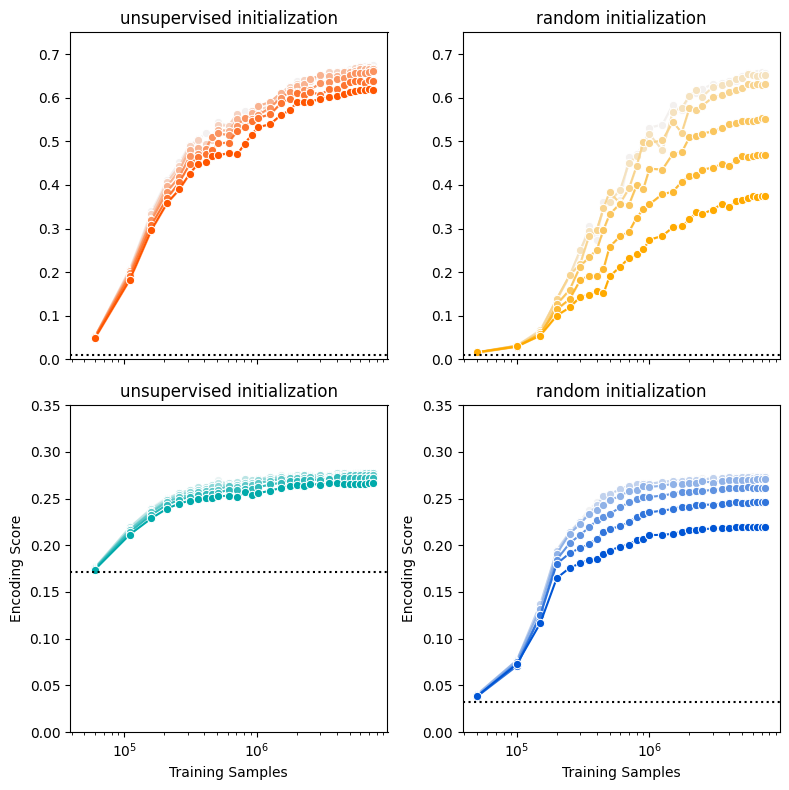

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharex=True)

# constant to convert epochs → samples
samples_per_epoch = 50_000 / 391

for col, (encoding_label, title) in enumerate(zip(
        ['lr0.001_randomFalse_staticNormTrue_10k_new',
         'lr0.001_randomTrue_staticNormTrue_10kRand_new'],
        ['unsupervised initialization', 'random initialization'])):

    # assign base colors per model type
    if title == 'unsupervised initialization':
        base_color_class = classification_palette[0]
        base_color_enc   = encoding_palette[1]
    else:
        base_color_class = classification_palette[1]
        base_color_enc   = encoding_palette[0]

    # --- TOP ROW: Classification Accuracy vs training samples ---
    ax_top = axes[0, col]
    df_class = load_encoding_results(encoding_label=encoding_label)
    df_class = df_class[df_class['ckpt_epoch'] != 0].copy()
    df_class['model_label'] = df_class['model_label'].replace(label_mapping)
    df_class = df_class.sort_values('model_label')

    # compute training_samples with different offsets
    df_class['training_samples'] = df_class['ckpt_epoch'] * samples_per_epoch
    if encoding_label == 'lr0.001_randomFalse_staticNormTrue_10k_new':
        df_class['training_samples'] += 10_000

    # plot
    unique_models = df_class['model_label'].unique()
    palette_class = sns.light_palette(base_color_class, n_colors=len(unique_models))
    sns.lineplot(
        data=df_class,
        x='training_samples',
        y='eval_accuracy',
        hue='model_label',
        marker='o',
        palette=palette_class,
        ax=ax_top,
        legend=False,
    )
    ax_top.set_xscale('log')
    ax_top.set_ylim(0, 0.75)
    ax_top.set_ylabel('')
    ax_top.set_xlabel('')
    ax_top.set_title(title)
    ax_top.axhline(y=0.01, color='black', linestyle=':')

    # --- BOTTOM ROW: Encoding Score vs training samples ---
    ax_bot = axes[1, col]
    df_enc = load_encoding_results(encoding_label=encoding_label)
    df_enc = df_enc[df_enc['ckpt_epoch'] != 0].copy()
    df_enc = df_enc[(df_enc['layerid'] == 10) & (df_enc['roi'] == "ventral visual stream")]
    df_enc['model_label'] = df_enc['model_label'].replace(label_mapping)
    df_enc = df_enc.sort_values('model_label')

    # compute training_samples with different offsets
    df_enc['training_samples'] = df_enc['ckpt_epoch'] * samples_per_epoch
    if encoding_label == 'lr0.001_randomFalse_staticNormTrue_10k_new':
        df_enc['training_samples'] += 10_000

    unique_models_enc = df_enc['model_label'].unique()
    palette_enc = sns.light_palette(base_color_enc, n_colors=len(unique_models_enc))
    sns.lineplot(
        data=df_enc,
        x='training_samples',
        y='encoding_score',
        hue='model_label',
        marker='o',
        palette=palette_enc,
        ax=ax_bot,
        legend=False,
        ci=None,
    )
    ax_bot.set_xscale('log')
    ax_bot.set_ylim(0, 0.35)
    ax_bot.set_ylabel('Encoding Score')
    ax_bot.set_xlabel('Training Samples')
    ax_bot.set_title(title)
    # baselines
    if title == 'unsupervised initialization':
        ax_bot.axhline(baseline_pca, color='black', linestyle=':')
    else:
        ax_bot.axhline(baseline_rand, color='black', linestyle=':')

plt.tight_layout()
plt.show()


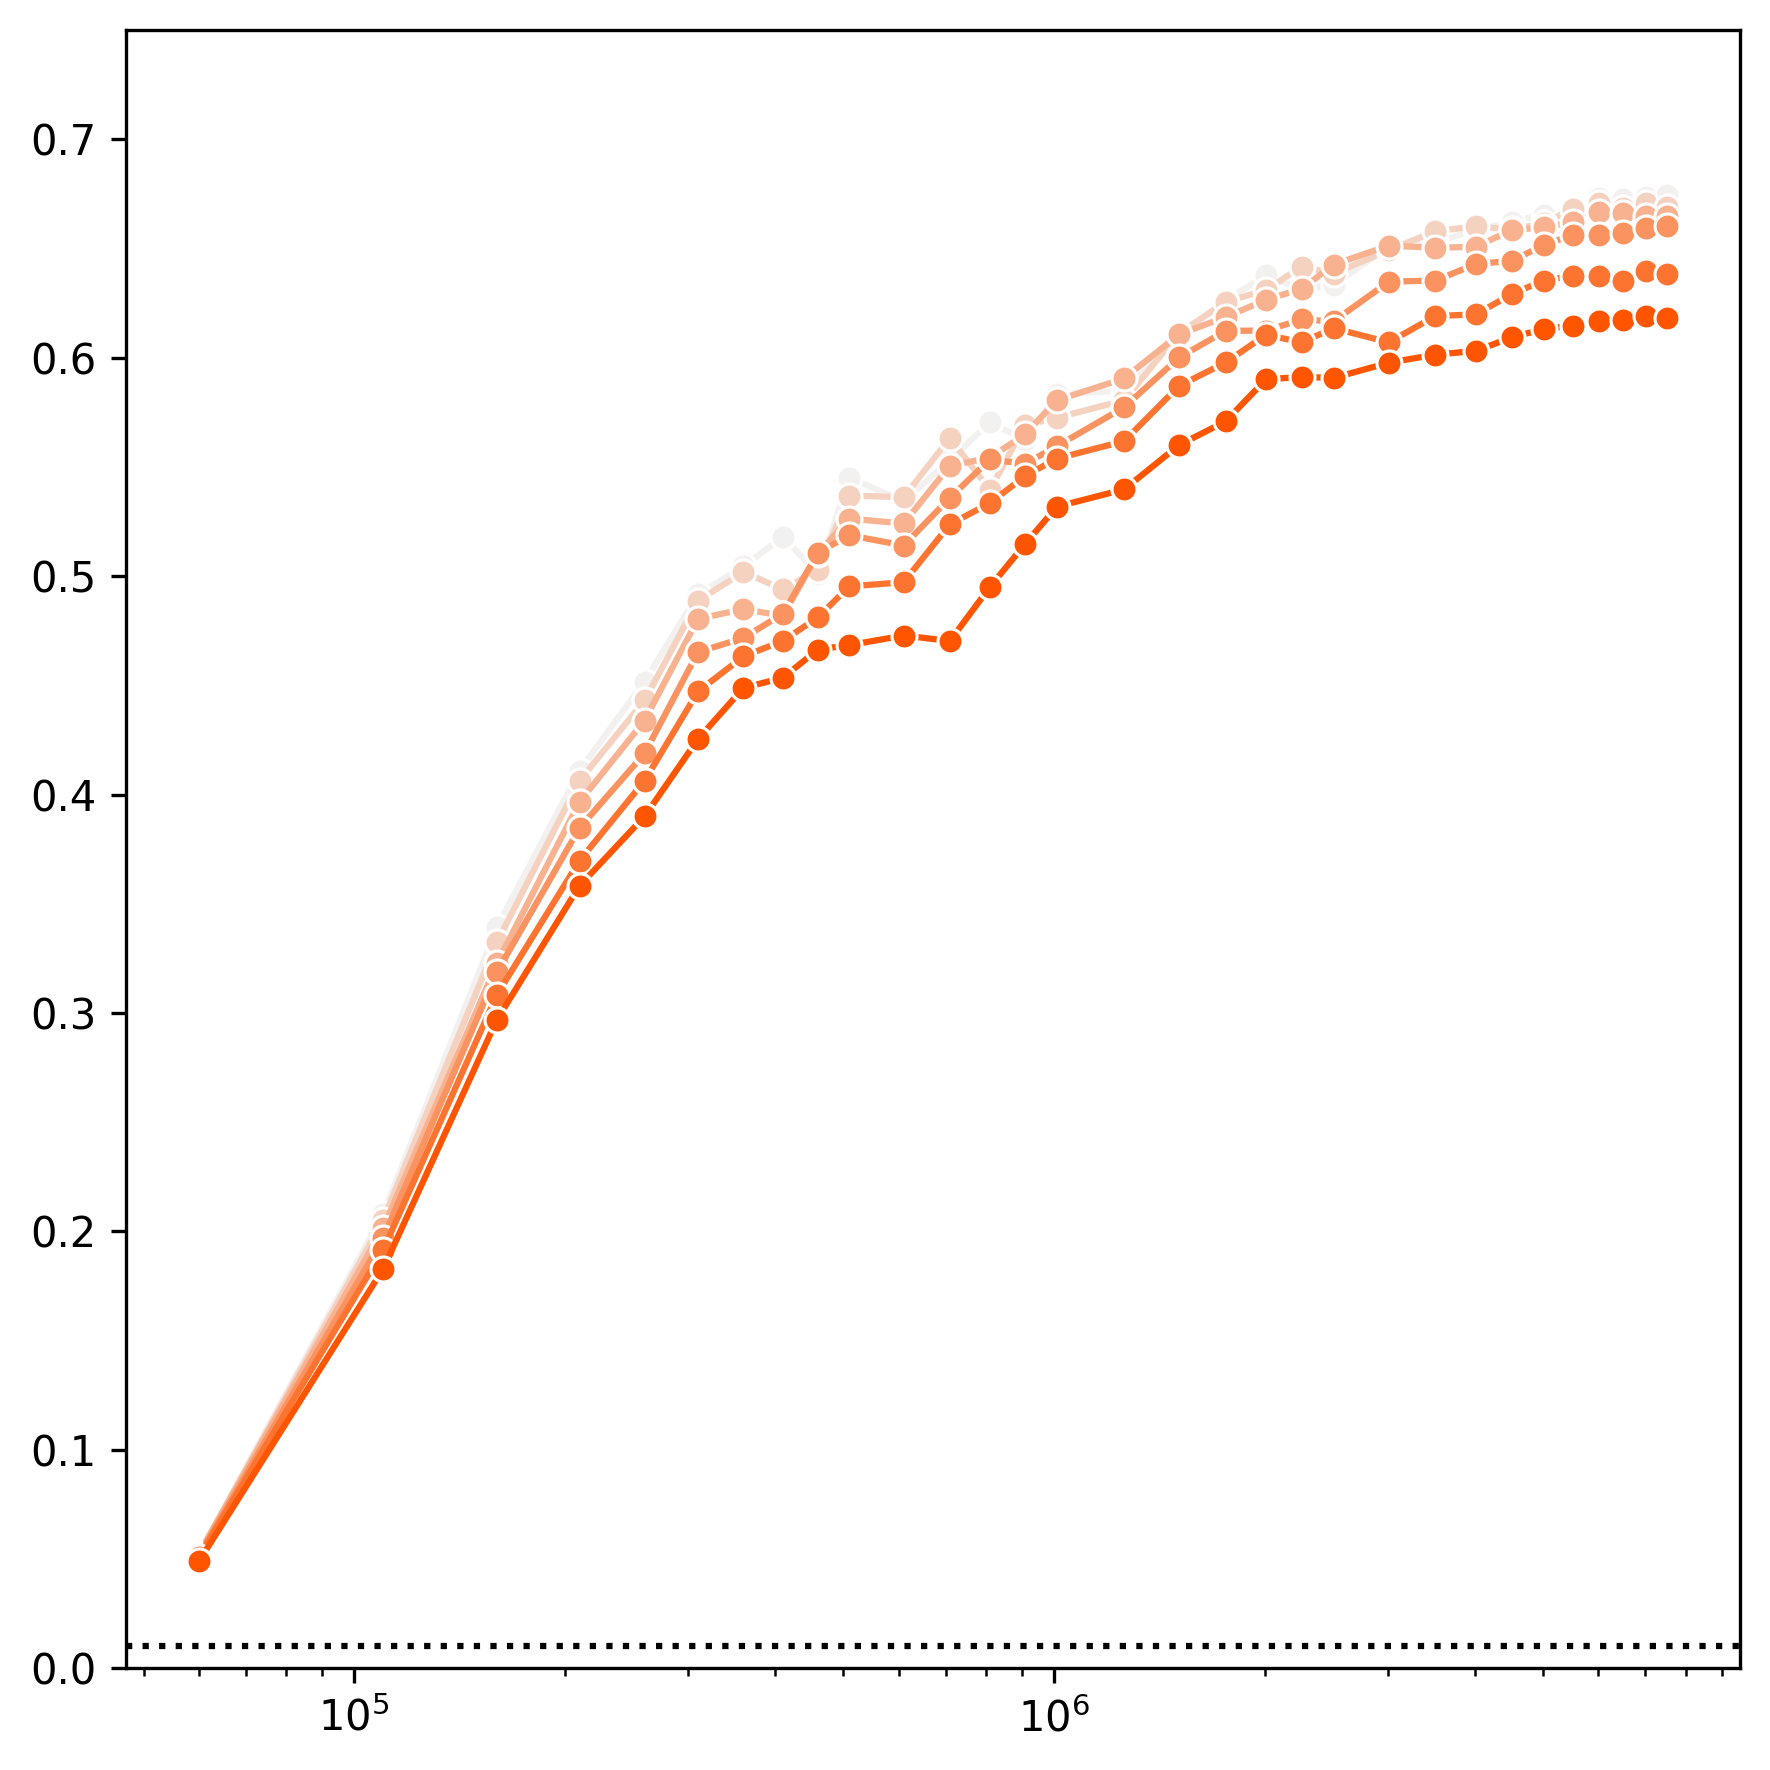

In [10]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
encoding_label = 'lr0.001_randomFalse_staticNormTrue_10k_new'
df = load_encoding_results(encoding_label=encoding_label)

df = df[df['ckpt_epoch'] != 0].copy()
df['training_samples'] = df['ckpt_epoch'] * (50_000 / 391) + 10_000
df['model_label'] = df['model_label'].replace(label_mapping)
df = df.sort_values('model_label')

base = classification_palette[0]
palette = sns.light_palette(base, n_colors=df['model_label'].nunique())
g = sns.lineplot(
    data=df, x='training_samples', y='eval_accuracy',
    hue='model_label', marker='o',
    palette=palette, ax=ax, legend=False
)

ax.set_xscale('log')
ax.set_ylim(0, 0.75)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.axhline(y=0.01, color='black', linestyle=':')
g.figure.set_dpi(300)
plt.tight_layout()
plt.show()


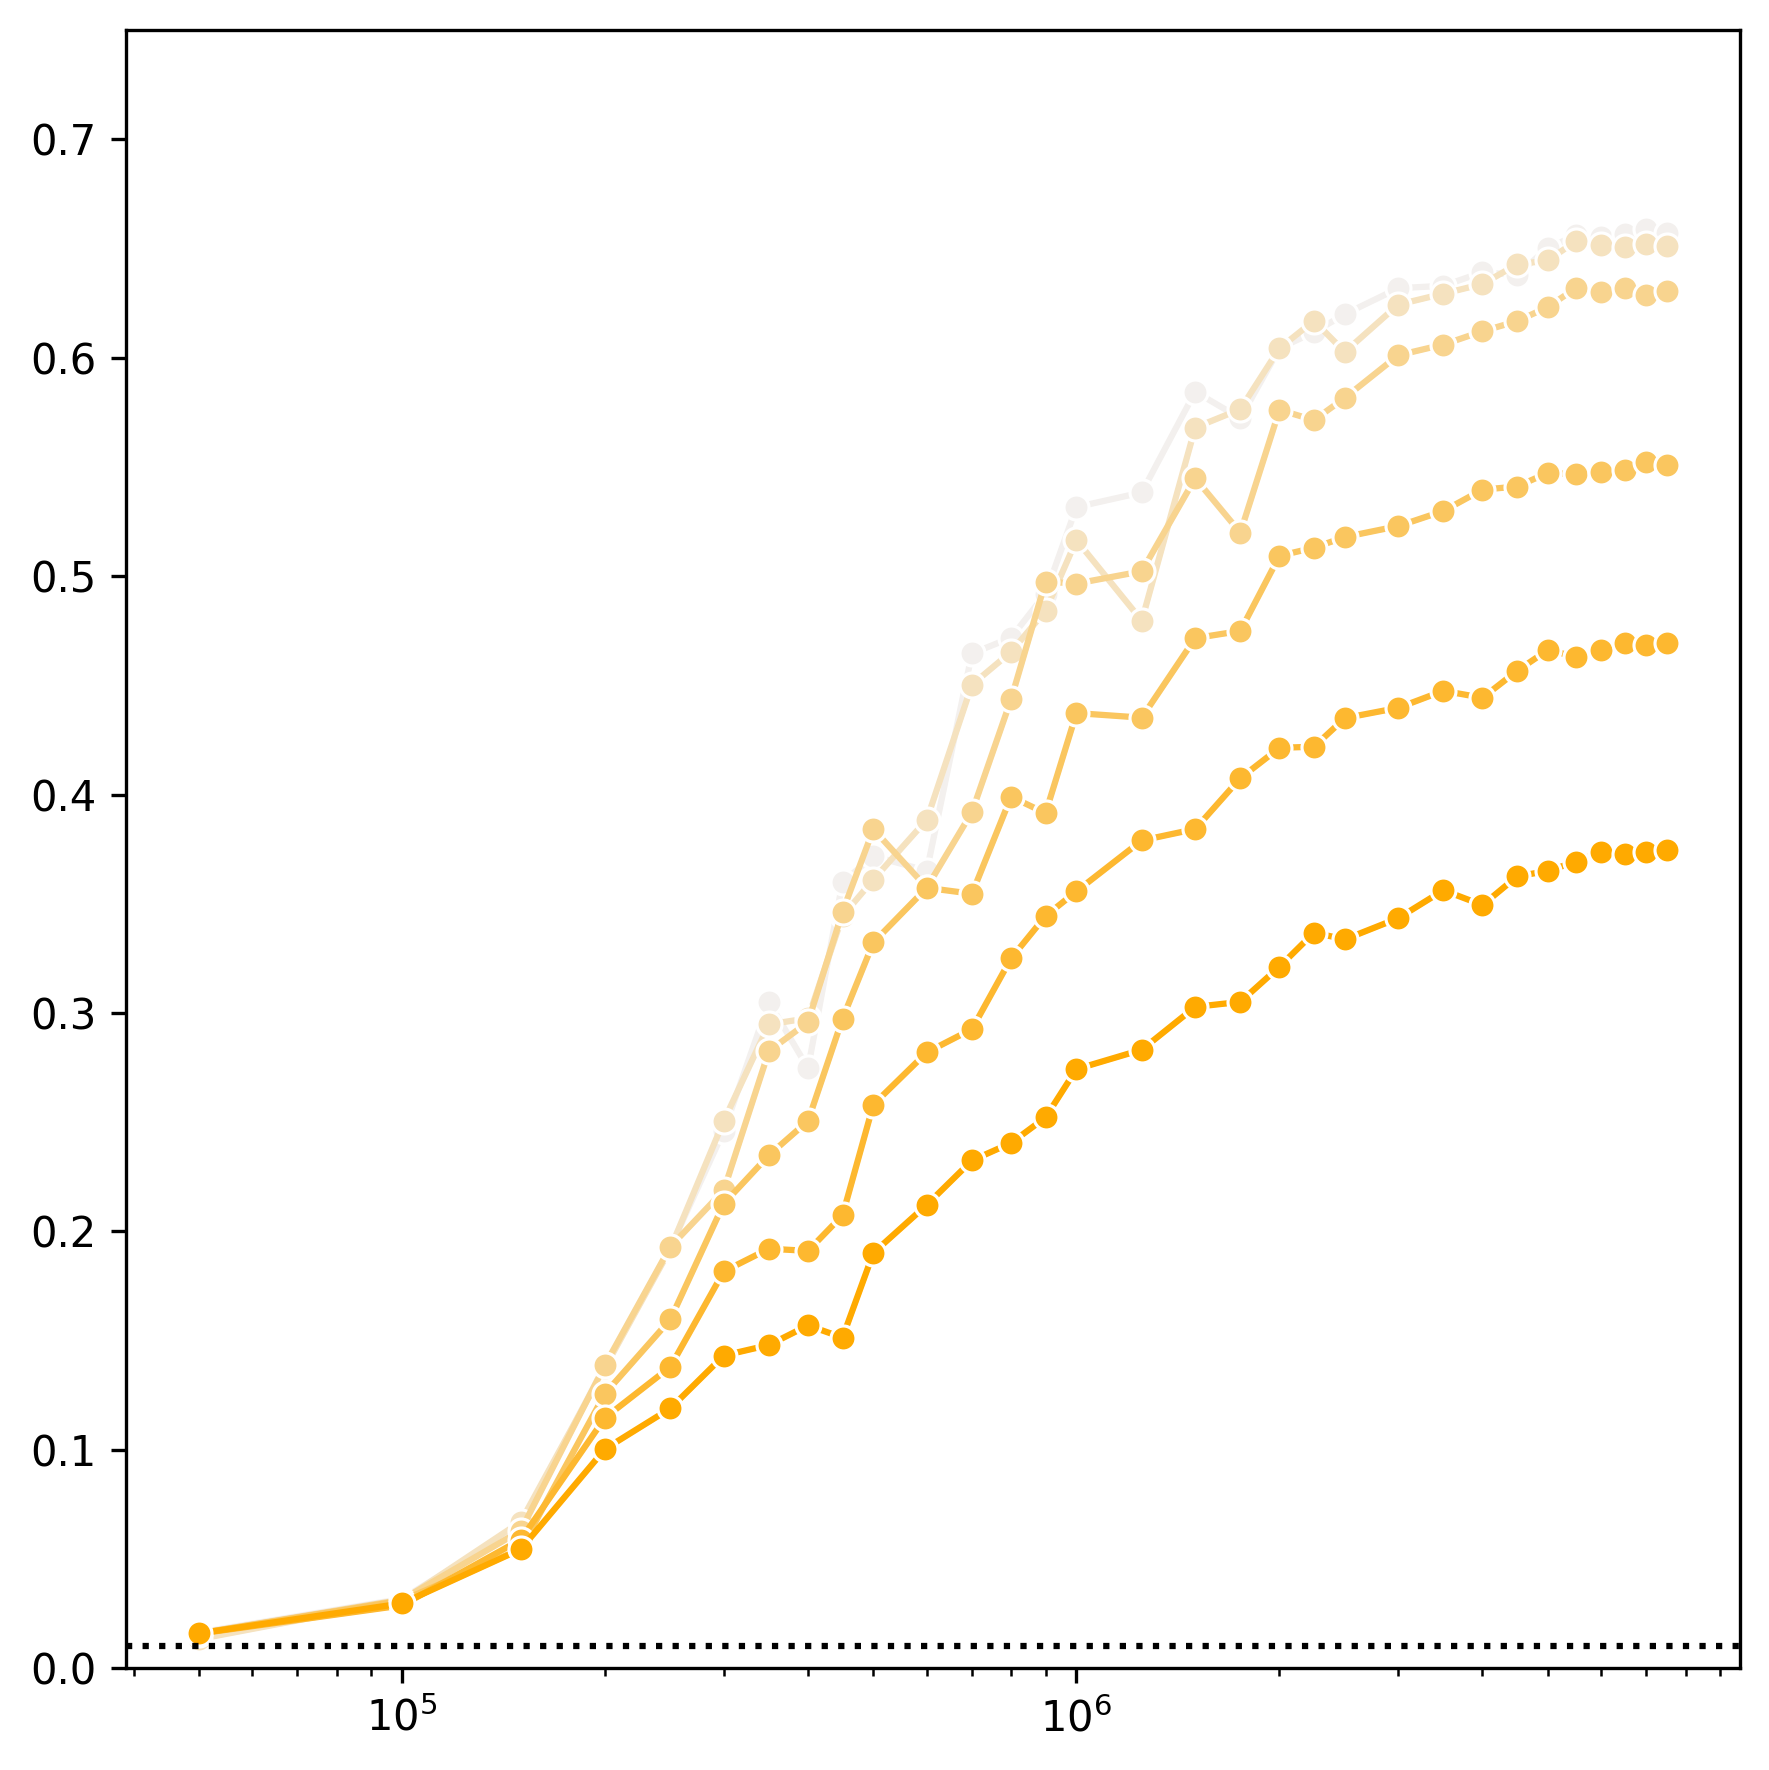

In [11]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
encoding_label = 'lr0.001_randomTrue_staticNormTrue_10kRand_new'
df = load_encoding_results(encoding_label=encoding_label)

df = df[df['ckpt_epoch'] != 0].copy()
df['training_samples'] = df['ckpt_epoch'] * (50_000 / 391)
df['model_label'] = df['model_label'].replace(label_mapping)
df = df.sort_values('model_label')

base = classification_palette[1]
palette = sns.light_palette(base, n_colors=df['model_label'].nunique())
g = sns.lineplot(
    data=df, x='training_samples', y='eval_accuracy',
    hue='model_label', marker='o',
    palette=palette, ax=ax, legend=False
)

ax.set_xscale('log')
ax.set_ylim(0, 0.75)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.axhline(y=0.01, color='black', linestyle=':')
g.figure.set_dpi(300)
plt.tight_layout()
plt.show()


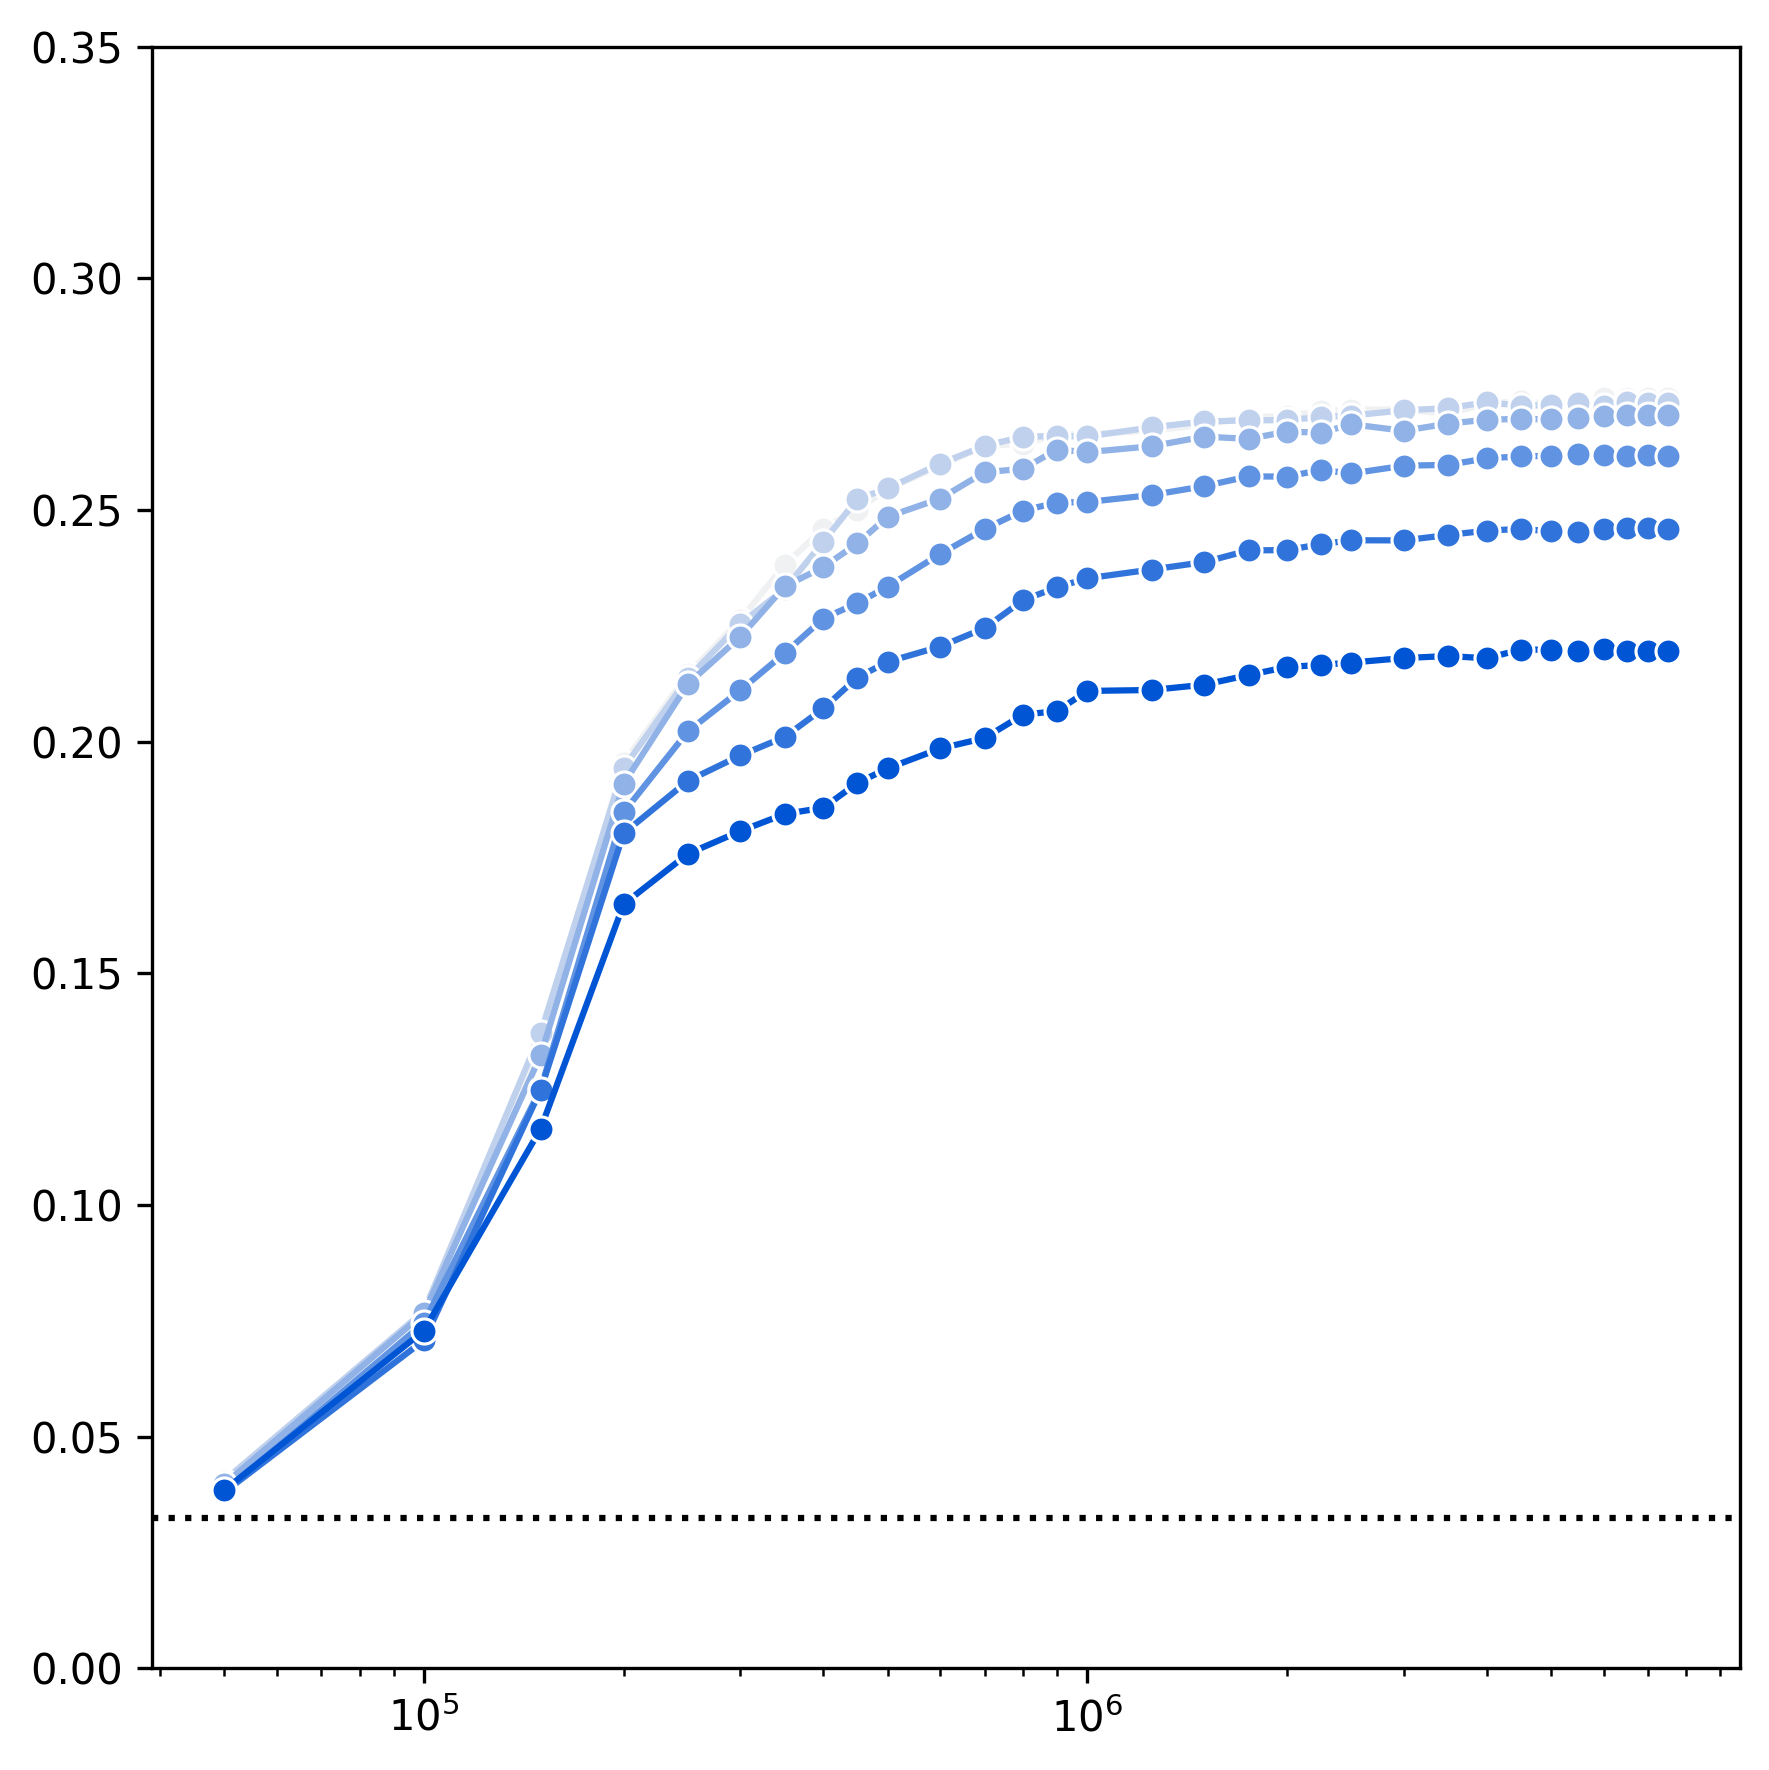

In [8]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
encoding_label = 'lr0.001_randomTrue_staticNormTrue_10kRand_new'
df = load_encoding_results(encoding_label=encoding_label)

df = df[(df['ckpt_epoch'] != 0) &
        (df['layerid'] == 10) &
        (df['roi'] == "ventral visual stream")].copy()
df['training_samples'] = df['ckpt_epoch'] * (50_000 / 391)
df['model_label'] = df['model_label'].replace(label_mapping)
df = df.sort_values('model_label')

base = encoding_palette[0]
palette = sns.light_palette(base, n_colors=df['model_label'].nunique())
g = sns.lineplot(
    data=df, x='training_samples', y='encoding_score',
    hue='model_label', marker='o',
    palette=palette, ax=ax, legend=False, ci=None
)

ax.set_xscale('log')
ax.set_ylim(0, 0.35)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.axhline(y=baseline_rand, color='black', linestyle=':')
g.figure.set_dpi(300)
plt.tight_layout()
plt.show()


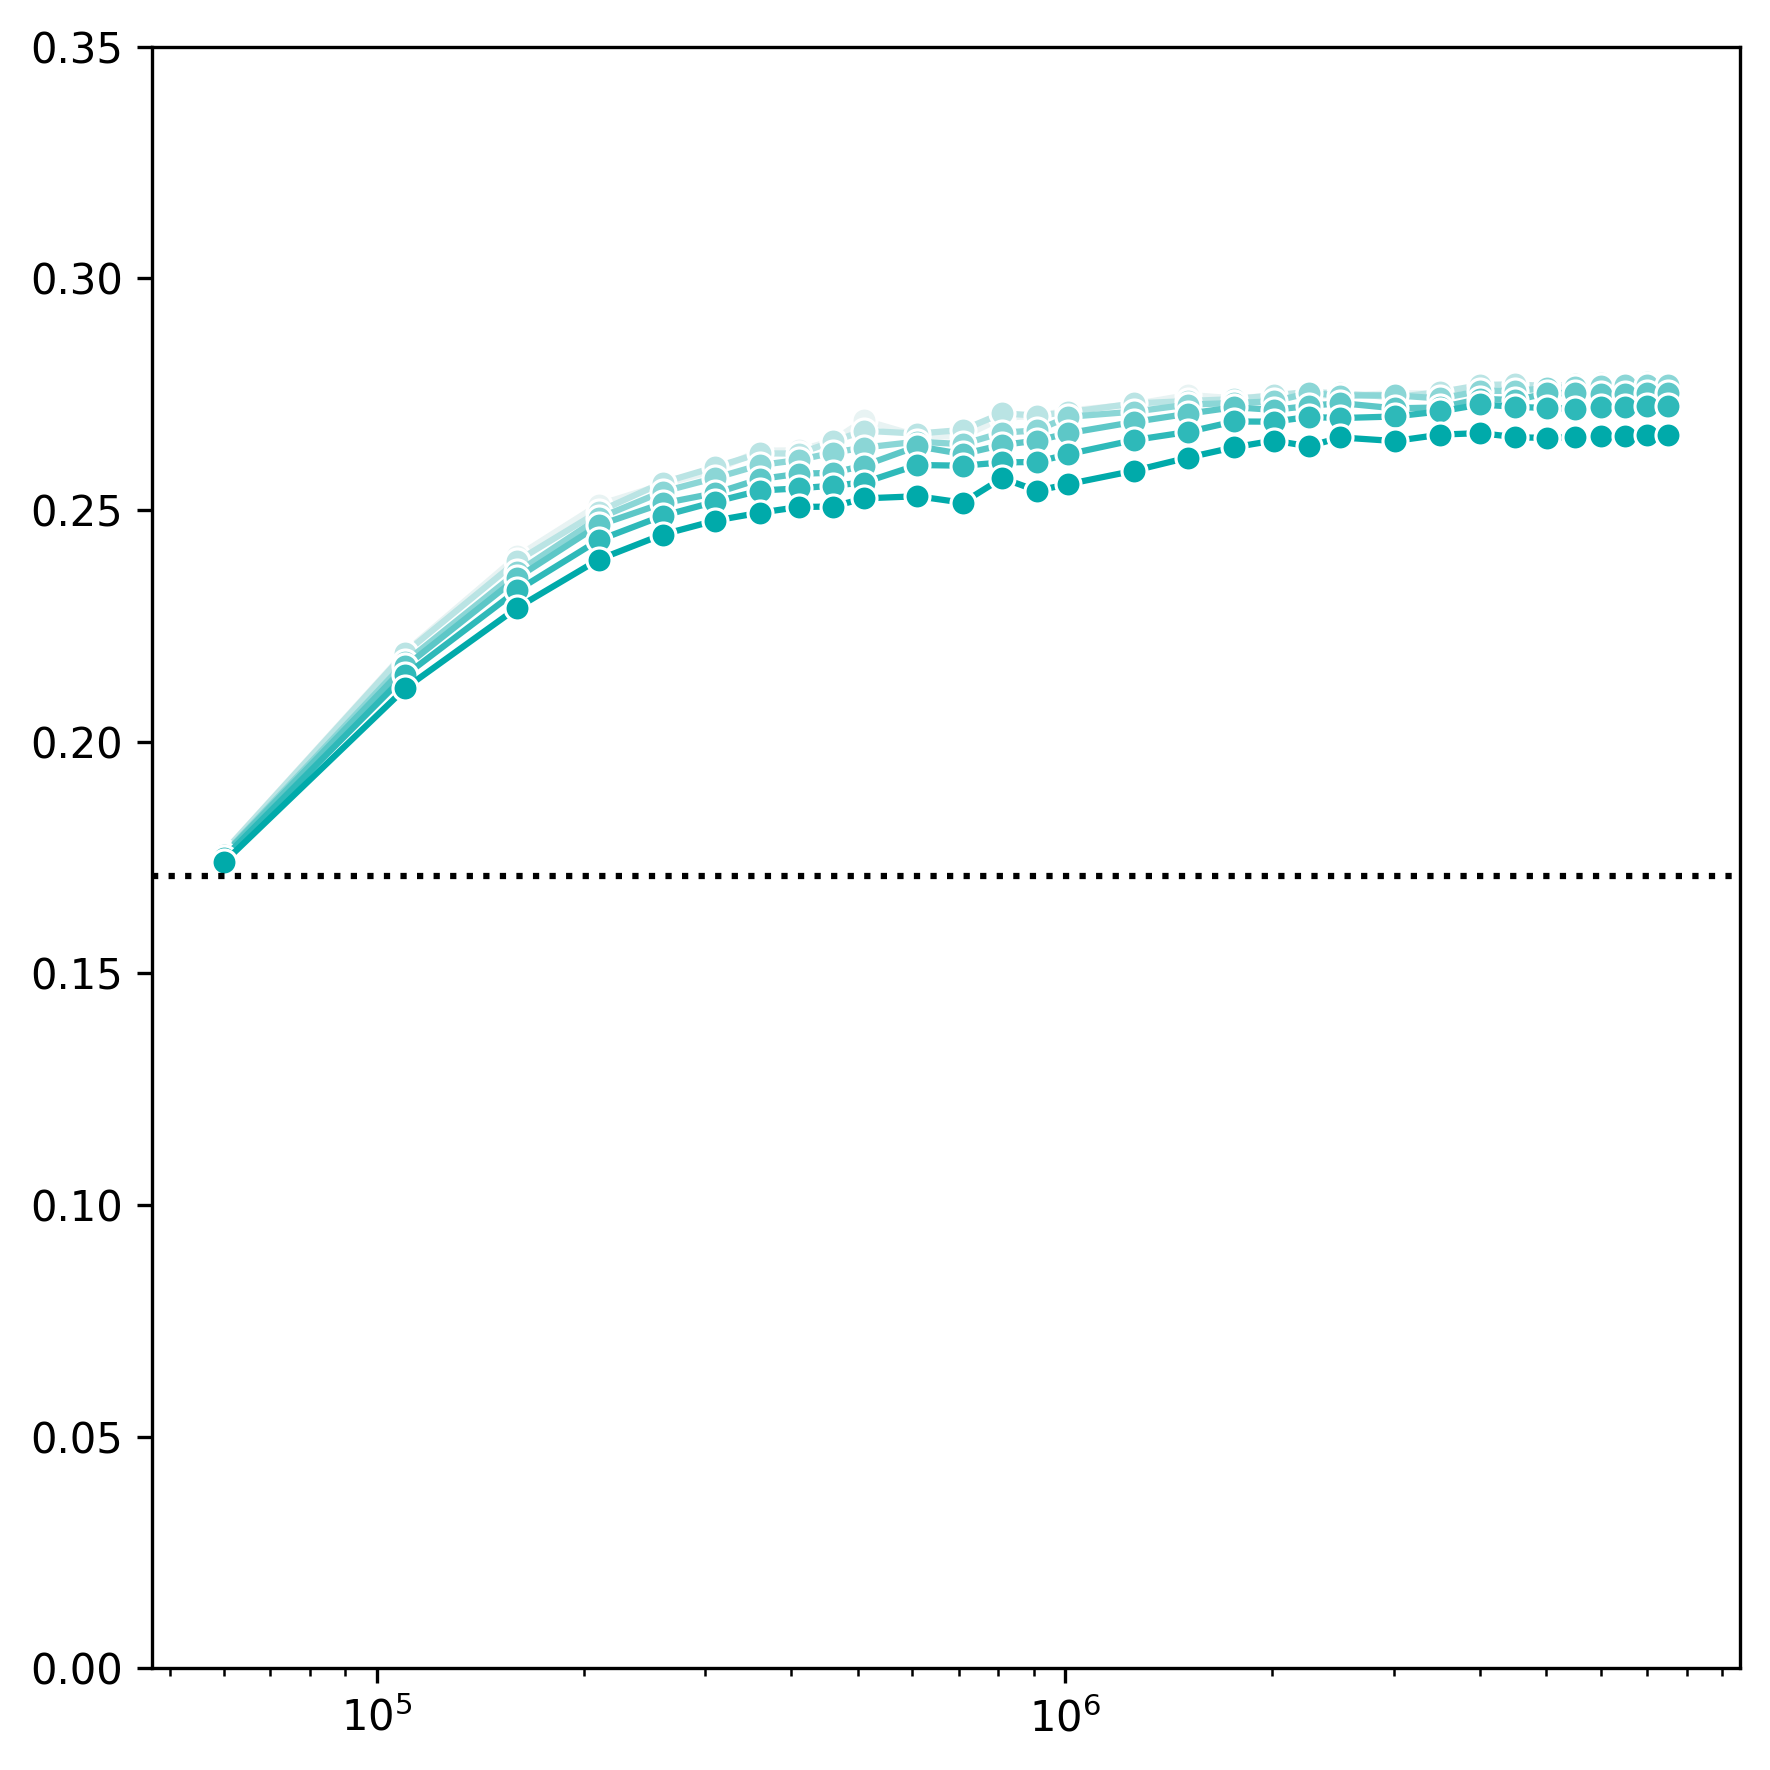

In [9]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
encoding_label = 'lr0.001_randomFalse_staticNormTrue_10k_new'
df = load_encoding_results(encoding_label=encoding_label)

df = df[(df['ckpt_epoch'] != 0) &
        (df['layerid'] == 10) &
        (df['roi'] == "ventral visual stream")].copy()
df['training_samples'] = df['ckpt_epoch'] * (50_000 / 391) + 10_000
df['model_label'] = df['model_label'].replace(label_mapping)
df = df.sort_values('model_label')

base = encoding_palette[1]
palette = sns.light_palette(base, n_colors=df['model_label'].nunique())
g = sns.lineplot(
    data=df, x='training_samples', y='encoding_score',
    hue='model_label', marker='o',
    palette=palette, ax=ax, legend=False, ci=None
)

ax.set_xscale('log')
ax.set_ylim(0, 0.35)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.axhline(y=baseline_pca, color='black', linestyle=':')
g.figure.set_dpi(300)
plt.tight_layout()
plt.show()
